In [18]:
import torch
from image_processing import read_img
from sklearn.model_selection import train_test_split
import os
from UNet import UNet,load_training_patches

device="cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
print(f"Used device: {device}")

#CONSTANTS
INPUT_DIR:str="./images"
MANUAL_DIR:str="./manual1"
MASK_DIR:str="./mask"
SAVED_MODELS:str="./saved_models"

#PATHS
input_images=[INPUT_DIR+"/"+file.name for file in os.scandir(INPUT_DIR) if file.is_file()]
manual_images=[MANUAL_DIR+"/"+file.name for file in os.scandir(MANUAL_DIR) if file.is_file()]
mask_images=[MASK_DIR+"/"+file.name for file in os.scandir("./mask") if file.is_file()]

Used device: cuda


In [19]:

print(torch.cuda.get_device_name(0))

total_vram = torch.cuda.get_device_properties(0).total_memory

print(f"VRAM: {total_vram / 1024**3:.2f} GB")

NVIDIA GeForce RTX 4050 Laptop GPU
VRAM: 6.00 GB


In [20]:
model = UNet(1).to(device)
print(f"The model will be trained on {next(model.parameters()).device}")

epochs=5_000
batch_size=8
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
X,y=load_training_patches(input_images,manual_images,percent_of_images=0.80,device=device)
X_train_patches, X_test, Y_train_patches, y_test = train_test_split(X,y, test_size=0.25, random_state=42)
num_train_samples = X_train_patches.size()[0]
old_ang_loss=float("inf")

The model will be trained on cuda:0


In [6]:

print("Started the training ")

for epoch in range(epochs):
    model.train()
    epoch_loss = 0

    permutation = torch.randperm(num_train_samples)

    for i in range(0, num_train_samples, batch_size):
        indices = permutation[i : i + batch_size]

        batch_x = X_train_patches[indices].float().to(device)
        batch_y = Y_train_patches[indices].float().to(device)

        pred_y = model(batch_x)

        loss = criterion(pred_y, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / (num_train_samples / batch_size)
    if avg_loss<old_ang_loss:
        torch.save(model.state_dict(), SAVED_MODELS+"/"+'model_weights_best_found.pth')

    old_ang_loss=avg_loss
    if avg_loss<=0.0100:#zeby zapobiec przeuczeniu
        break
    if epoch%100==0:
        print(f"Epoch: {epoch + 1} z {epochs} Mean error: {avg_loss:.4f}")

Started the training 
Epoch: 1 z 5000 Mean error: 0.6362
Epoch: 101 z 5000 Mean error: 0.1201
Epoch: 201 z 5000 Mean error: 0.0633
Epoch: 301 z 5000 Mean error: 0.0337
Epoch: 401 z 5000 Mean error: 0.0247
Epoch: 501 z 5000 Mean error: 0.0246
Epoch: 601 z 5000 Mean error: 0.0178
Epoch: 701 z 5000 Mean error: 0.0196
Epoch: 801 z 5000 Mean error: 0.0171
Epoch: 901 z 5000 Mean error: 0.0165
Epoch: 1001 z 5000 Mean error: 0.0142
Epoch: 1101 z 5000 Mean error: 0.0125
Epoch: 1201 z 5000 Mean error: 0.0137
Epoch: 1301 z 5000 Mean error: 0.0137
Epoch: 1401 z 5000 Mean error: 0.0121
Epoch: 1501 z 5000 Mean error: 0.0116
Epoch: 1601 z 5000 Mean error: 0.0117
Epoch: 1701 z 5000 Mean error: 0.0127
Epoch: 1801 z 5000 Mean error: 0.0112
Epoch: 1901 z 5000 Mean error: 0.0113
Epoch: 2001 z 5000 Mean error: 0.0115
Epoch: 2101 z 5000 Mean error: 0.0114
Epoch: 2201 z 5000 Mean error: 0.0111
Epoch: 2301 z 5000 Mean error: 0.0112


KeyboardInterrupt: 

In [12]:
torch.save(model.state_dict(), SAVED_MODELS+"/"+'model_weights_newest_512_size.pth')


In [8]:
model = UNet(1).to(device)
model.load_state_dict(torch.load(SAVED_MODELS+"/"+"model_weights_best_found.pth", weights_only=True))

<All keys matched successfully>

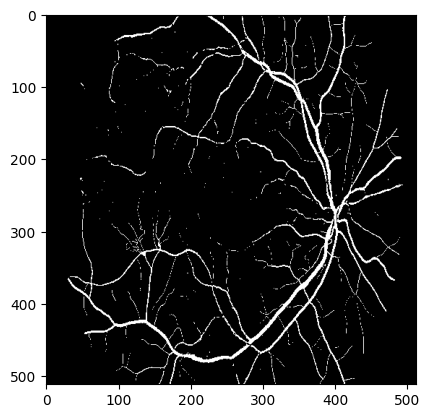

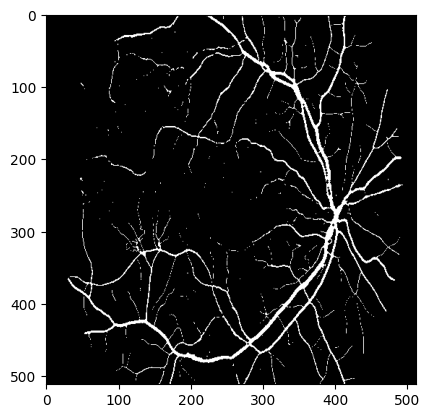

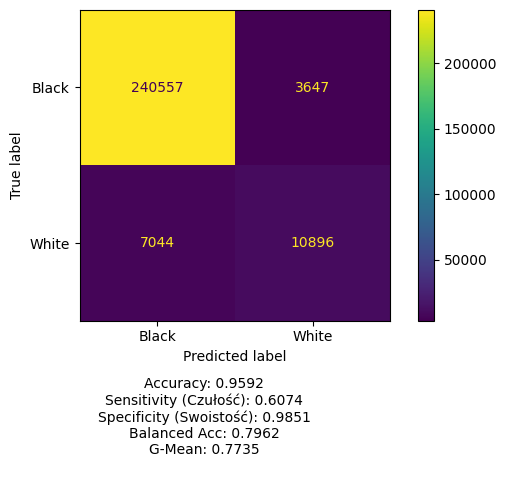

In [16]:
import gc
import cv2
import torch
import numpy as np
from image_processing import show_img
from simple_statistics import create_confusions_matrix
from image_processing import postproces_pipeline


image_path = "./images/13_dr.JPG"
mask_path  = "./manual1/13_dr.tif"   


gc.collect()
torch.cuda.empty_cache()


model.eval()


img = read_img(image_path)

mask =read_img(mask_path)
if len(mask.shape)>1:
            mask=mask[:,:,1]

#Zamian rozmiary pod ten stosowany podcxas treningu
size = 512
img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)
mask = cv2.resize(mask, (size, size), interpolation=cv2.INTER_NEAREST)

# Nornalizacja zdjec
img = img.astype(np.float32) / 255.0
img = np.transpose(img, (2, 0, 1))          # HWC -> CHW
img = np.expand_dims(img, axis=0)           # CHW -> NCHW

mask = (mask > 0).astype(np.uint8)


X = torch.tensor(img, dtype=torch.float32, device=device)


with torch.no_grad():
    result = model(X)
    result = torch.sigmoid(result)
    result = (result > 0.5).float()


# Przeniseiie na CPU i zmaian na numpy
pred = result.squeeze(0).squeeze(0).cpu().numpy().astype(np.uint8)
show_img(pred)
pred=postproces_pipeline(pred,3)
show_img(pred)
true = mask.astype(np.uint8)


# --- upewnienie się, że rozmiary są identyczne ---
h = min(true.shape[0], pred.shape[0])
w = min(true.shape[1], pred.shape[1])

true = true[:h, :w]
pred = pred[:h, :w]

# --- macierz pomyłek ---
create_confusions_matrix(
    true.flatten(),
    pred.flatten()
)